# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from Multifidelity_support import custom_activation, getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity, Neural_network
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
from keras.models import load_model

from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform


from cuqi.distribution import Uniform, Gaussian,JointDistribution
from cuqi.sampler import MH
from cuqi.model import Model
from cuqi.geometry import Continuous1D, Discrete

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [3]:
custom_objects = {'custom_activation': custom_activation, 'glorot_uniform': glorot_uniform()}

with custom_object_scope(custom_objects):
    keras_model1 = load_model("LF_model.h5")
    keras_model2= load_model("2step_model.h5")

def NN_MF(q,K1,K2):
    out1=K1.predict(q)
 #   print(q.shape)
    #in2 = np.hstack((q, out1))
    in2=np.concatenate((q,out1),axis=1)

    approx_model_output=K2.predict(in2)
    return approx_model_output

def MF_wrapper(q):
    return NN_MF(1,keras_model1,keras_model2)

OSError: No file or directory found at LF_model.h5

## Data Preparation

In [ ]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = "../DATA/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

In [ ]:
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)

reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test



reaction_LF_test = normalization(reaction_LF_test)
U_LF_test=U_LF_test[
    :,
     - 1,
    12,12
]
U_LF_test=normalization(U_LF_test)
reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
U_LF_test_original=U_LF_test


## Neural Network


In [ ]:
real_x = np.linspace([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 400  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

In [ ]:
A_MF=Model(forward=MF_wrapper, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
y_obs=y_MF(x_MF=real_x).sample()
posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_MF=MH(posterior_MF,x0=x_init)
samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

samplesMH_MF.plot_trace()
samplesMH_MF.mean()
samplesMH_MF.compute_ess()
samplesMH_MF.plot_autocorrelation()

### Low fidelity

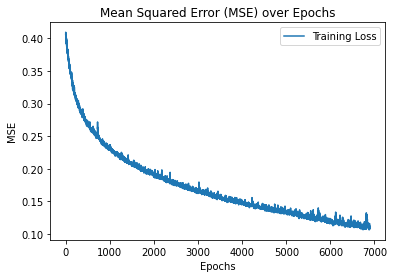

Test MSE: 0.045842277770442044
R^2: 0.6275795035753469


In [ ]:

name="LF"
K.clear_session()
best_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
modelLF=Neural_network(name,params=best_params,data_train=reaction_LF,output_train=U_train_LF,N=Nepo[0],n=batch_size[0],train=True,do_HPO=False,verbose=False)


ULF = modelLF.prediction(reaction_LF_test_original)
(test_mse_LF,r2_LF) = modelLF.performance(reaction_LF_test_original,U_LF_test_original)



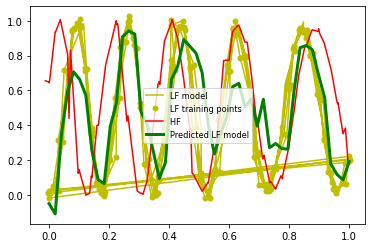

In [ ]:
plt.figure()
plt.plot(
reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
)
plt.plot(
reaction_LF[:, 0],
U_train_LF,
"yo",
markersize=5,
label="LF training points",
)
order=np.argsort(reaction_HF[:,0])
plt.plot(
reaction_HF[order, 0],
U_HF[order],
"r-",
markersize=5,
label="HF ",
)
plt.plot(
reaction_LF_test_original[:, 0],
ULF,
"g-",
linewidth=3,
label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

### High Fidelity

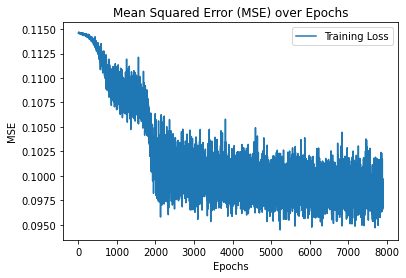

Test MSE: 0.09966862095636868
R^2: 0.11952571575955284


In [ ]:

name="HF"
K.clear_session()
best_params ={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

modelHF=Neural_network(name,params=best_params,data_train=reaction_HF,output_train=U_HF,N=Nepo[1],n=batch_size[1],train=True,do_HPO=False,verbose=False)


UHF = modelHF.prediction(reaction_HF_test_original)
(test_mse_HF,r2_HF) = modelHF.performance(reaction_HF_test_original,U_HF_test_original)



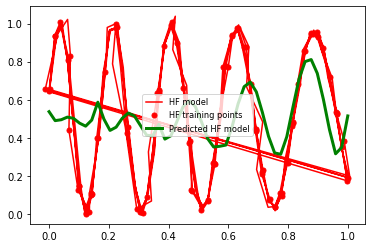

In [ ]:
plt.figure()
plt.plot(
reaction_HF_test[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
)
plt.plot(
reaction_HF[:, 0],
U_HF,
"ro",
markersize=5,
label="HF training points",
)
plt.plot(
reaction_HF_test_original[:, 0],
UHF,
"g-",
linewidth=3,
label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

### Multifidelity

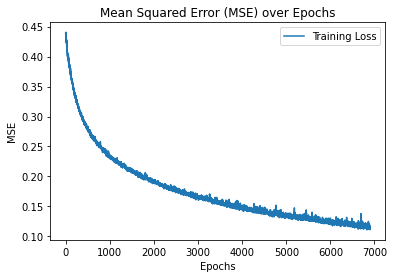

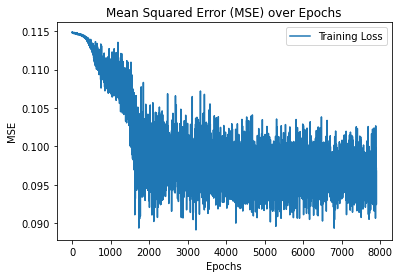

Test MSE: 0.10099531834218708
R^2: 0.1078056486012694


In [ ]:
##########################       FIRST NN: NN_LF     ##########################
K.clear_session()
names=["LF","2step"]

bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # obtained
bestHF_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params=[bestLF_params, bestHF_params]


final_model= MultiFidelity(names,params=params,data_train_LF=reaction_LF,output_train_LF=U_train_LF,data_train_HF=reaction_HF, output_train_HF=U_HF,N=Nepo,n=batch_size,verbose=False)




input_HF = np.concatenate(
    (reaction_HF_test_original,  final_model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF

input_HF_train = np.concatenate(
    (reaction_HF,  final_model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
) 

(test_mse_HF,r2_HF) = final_model.model_list[1].performance(input_HF,U_HF_test_original)



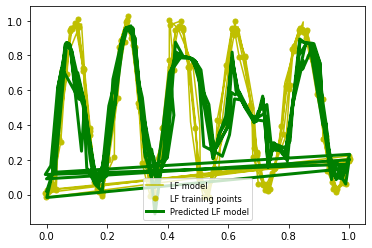

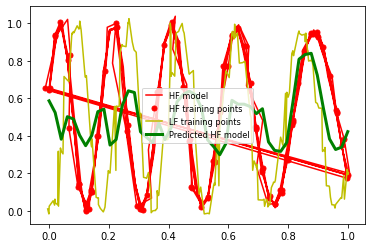

In [ ]:


                
plt.figure()
plt.plot(
reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
)
plt.plot(
reaction_LF[:, 0],
U_train_LF,
"yo",
markersize=5,
label="LF training points",
)
plt.plot(
reaction_LF_test[:, 0],
final_model.model_list[0].prediction(reaction_LF_test),
"g-",
linewidth=3,
label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

plt.figure()
plt.plot(
reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
)
plt.plot(
input_HF_train[:, 0],
U_HF,
"ro",
markersize=5,
label="HF training points",
)


order=np.argsort(reaction_LF[:,0])

plt.plot(
reaction_LF[order,0],
U_train_LF[order],
"y-",
markersize=5,
label="LF training points",
)
plt.plot(
input_HF[:, 0],
final_model.model_list[1].prediction(input_HF),
"g-",
linewidth=3,
label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

## MCMC

In [ ]:
real_x=reaction_HF_test
observed_output=U_HF_test

# Set parameters for the MCMC
n_samples = 400  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

In [ ]:
# ATTENZIONE!  in caso LF non si dovrebbe mettere comunque forward=modelHF?


A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_LF=Gaussian(mean=A_LF(x_LF),cov=proposal_sd)
y_obs=y_LF(x_LF=real_x).sample()
posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_LF=MH(posterior_LF,x0=x_init)
samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,n_samples)    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two

samplesMH_LF.plot_trace()
print("mean value")
print(samplesMH_LF.mean())
print("ESS")
print(samplesMH_LF.compute_ess())
samplesMH_LF.plot_autocorrelation()

ValueError: operands could not be broadcast together with shapes (250,1) (5,1) 

In [ ]:
A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
y_obs=y_HF(x_HF=real_x).sample()
posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_HF=MH(posterior_HF,x0=x_init)
samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

samplesMH_HF.plot_trace()
print(samplesMH_HF.mean())
print(samplesMH_HF.compute_ess())
samplesMH_HF.plot_autocorrelation()

In [ ]:
A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
y_obs=y_MF(x_MF=real_x).sample()
posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_MF=MH(posterior_MF,x0=x_init)
samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

samplesMH_MF.plot_trace()
samplesMH_MF.mean()
samplesMH_MF.compute_ess()
samplesMH_MF.plot_autocorrelation()